# Bauer & Swanson (2023) 再現

> Bauer, M. D., & Swanson, E. T. (2023). An Alternative Explanation for the 'Fed Information Effect'. *AER*, 113(3), 664-700.

詳細は [README.md](../README.md) を参照。本ノートブックは結果の表示用。

**核心**: raw mps は 6 つの事前マクロ変数で予測可能 (R²=0.156, p<0.0001)。mps_orth は予測不可能 (R²=0.001) → 直交化が機能。Treasury yield 反応は 両者でほぼ同一 (β diff < 0.02) → 構造的 MP 効果は保存される。


In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

# Repository-relative paths
PAPER_DIR = Path.cwd() if (Path.cwd().name == "bauer_swanson_2023") else Path("..").resolve()
RESULTS = PAPER_DIR / "results"
SCRIPT = PAPER_DIR / "scripts" / "replicate.py"

# Sanity check
print(f"Paper dir: {PAPER_DIR}")
print(f"Results dir exists: {RESULTS.exists()}")
print(f"Script: {SCRIPT} exists: {SCRIPT.exists()}")


Paper dir: /home/tarai/Research/FI-research/projects/replications/bauer_swanson_2023
Results dir exists: True
Script: /home/tarai/Research/FI-research/projects/replications/bauer_swanson_2023/scripts/replicate.py exists: True


## (オプション) 再実行

未実行 or データ更新後に走らせる。既存結果があればスキップしてよい。

```bash
python projects/replications/bauer_swanson_2023/scripts/replicate.py
```


## 結果テーブル

In [2]:
print('=' * 60)
print('Table: predictability_mps.csv')
print('=' * 60)
display(pd.read_csv(RESULTS / 'predictability_mps.csv'))

print('=' * 60)
print('Table: shock_response.csv')
print('=' * 60)
display(pd.read_csv(RESULTS / 'shock_response.csv'))


Table: predictability_mps.csv


,lhs,model,predictor,coef,t,R2,n,R2_adj,F,F_pvalue,sample
0,mps,univariate(nfp_surp),nfp_surp,1.309078e-04,3.228333e+00,4.992184e-02,323,NaN,NaN,NaN,paper_full_1988_2019
1,mps,univariate(nfp_12m),nfp_12m,7.446831e-03,3.256717e+00,4.129859e-02,323,NaN,NaN,NaN,paper_full_1988_2019
2,mps,univariate(sp500_3m),sp500_3m,1.816599e-01,2.600425e+00,4.824838e-02,323,NaN,NaN,NaN,paper_full_1988_2019
3,mps,univariate(slope_3m),slope_3m,-2.530013e-02,-2.950049e+00,3.647196e-02,323,NaN,NaN,NaN,paper_full_1988_2019
4,mps,univariate(bcom_3m),bcom_3m,1.636885e-01,2.965304e+00,4.760524e-02,323,NaN,NaN,NaN,paper_full_1988_2019
5,mps,univariate(tr_skew),tr_skew,3.889725e-02,3.119245e+00,3.420059e-02,323,NaN,NaN,NaN,paper_full_1988_2019
6,mps,joint,ALL,NaN,NaN,1.563487e-01,323,0.140330,5.121910e+00,0.000049,paper_full_1988_2019
7,mps_orth,univariate(nfp_surp),nfp_surp,-1.936285e-06,-5.192144e-02,1.293362e-05,323,NaN,NaN,NaN,paper_full_1988_2019
8,mps_orth,univariate(nfp_12m),nfp_12m,-6.821921e-04,-3.353727e-01,4.104194e-04,323,NaN,NaN,NaN,paper_full_1988_2019
9,mps_orth,univariate(sp500_3m),sp500_3m,-1.505743e-03,-2.437373e-02,3.925442e-06,323,NaN,NaN,NaN,paper_full_1988_2019


Table: shock_response.csv


,response,response_label,shock,coef,se,t,R2,n,sample
0,sp500_emini,S&P 500 e-mini (30-min FOMC window),mps,-6.317439,0.987080,-6.400128,0.288098,188,paper_full_1988_2019
1,sp500_emini,S&P 500 e-mini (30-min FOMC window),mps_orth,-6.698559,1.276333,-5.248283,0.267288,188,paper_full_1988_2019
2,tnote02,2y Treasury yield Δ (FOMC window),mps,0.704559,0.041518,16.970016,0.773060,258,paper_full_1988_2019
3,tnote02,2y Treasury yield Δ (FOMC window),mps_orth,0.719372,0.042946,16.750720,0.686061,258,paper_full_1988_2019
4,tnote05,5y Treasury yield Δ (FOMC window),mps,0.614673,0.047261,13.006063,0.608647,307,paper_full_1988_2019
5,tnote05,5y Treasury yield Δ (FOMC window),mps_orth,0.627503,0.048390,12.967556,0.535496,307,paper_full_1988_2019
6,tnote10,10y Treasury yield Δ (FOMC window),mps,0.406478,0.044297,9.176213,0.428326,323,paper_full_1988_2019
7,tnote10,10y Treasury yield Δ (FOMC window),mps_orth,0.406176,0.042055,9.658147,0.361166,323,paper_full_1988_2019
8,tbond,30y Treasury bond yield Δ (FOMC window),mps,0.245111,0.040865,5.997990,0.197719,323,paper_full_1988_2019
9,tbond,30y Treasury bond yield Δ (FOMC window),mps_orth,0.248113,0.037649,6.590233,0.171081,323,paper_full_1988_2019


## 図

### info_effect_scatter.png

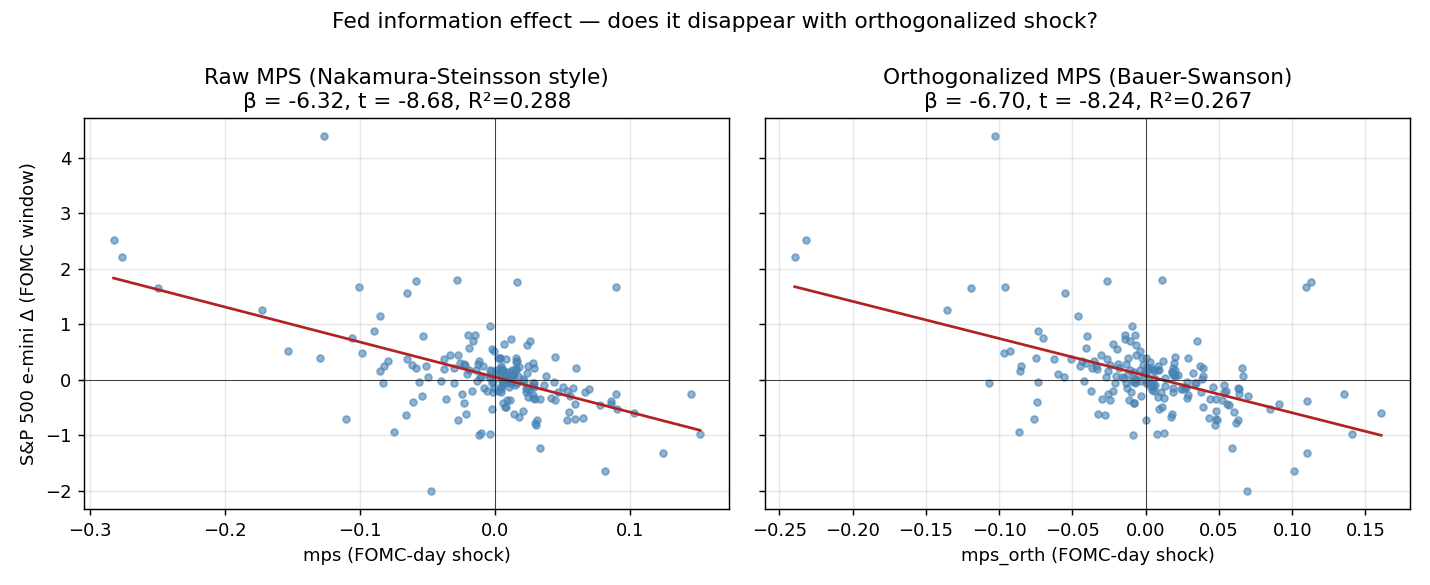

### response_coefficients.png

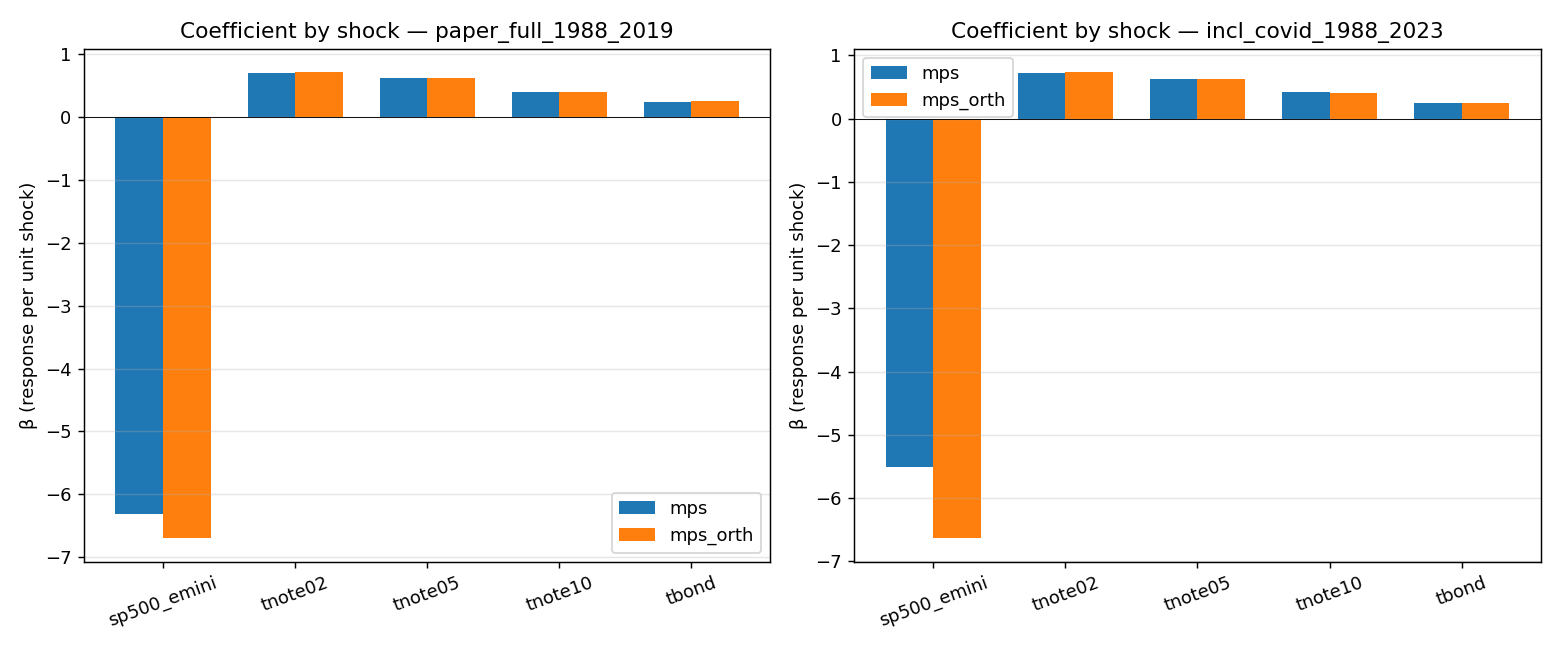

In [3]:
display(Markdown('### info_effect_scatter.png'))
display(Image(str(RESULTS / 'info_effect_scatter.png')))

display(Markdown('### response_coefficients.png'))
display(Image(str(RESULTS / 'response_coefficients.png')))
